In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install xgboost

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

RANDOM_STATE = 42

## 1. Load data and set X, y (same convention as Data_processing.ipynb)

In [2]:
df = pd.read_csv("delaney-processed.csv")

Target = 'measured log solubility in mols per litre'
features = ['Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
    'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area']

X = df[features]
y = df[Target]

print("X:", X.shape, "  y:", y.shape)

X: (1128, 6)   y: (1128,)


In [3]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.20, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} molecules")
print(f"Test : {X_test.shape[0]} molecules")

Train: 902 molecules
Test : 226 molecules


## 3. Evaluation helper

Returns RMSE, MAE, R² so every model reports the same three numbers.

In [4]:
def evaluate(name, y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<25s}  RMSE={rmse:.3f}   MAE={mae:.3f}   R2={r2:.3f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

## 5. Baseline 2 — Delaney's ESOL model

The `ESOL predicted` column is what Delaney's original 4-parameter linear model
scored. Evaluating it on our test set tells us what number we need to beat to
claim we've done better than the 2004 paper.

In [6]:
delaney_pred_test = df.loc[idx_test, 'ESOL predicted log solubility in mols per litre'].values
results.append(evaluate("Delaney's ESOL model", y_test, delaney_pred_test))

Delaney's ESOL model       RMSE=0.956   MAE=0.708   R2=0.807


## 6. Linear Regression

Ordinary least squares on the 6 features. No regularization, no scaling
(scaling doesn't affect OLS predictions — only their coefficients).

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(evaluate("Linear Regression", y_test, lr_pred))

# Show the fitted coefficients so we can sanity-check the signs
print("\nCoefficients:")
for f, c in zip(features, lr.coef_):
    print(f"  {f:<28s} {c:+.4f}")
print(f"  {'intercept':<28s} {lr.intercept_:+.4f}")

Linear Regression          RMSE=1.199   MAE=0.892   R2=0.696

Coefficients:
  Minimum Degree               -0.2751
  Molecular Weight             -0.0134
  Number of H-Bond Donors      +0.1083
  Number of Rings              -0.4068
  Number of Rotatable Bonds    -0.1513
  Polar Surface Area           +0.0310
  intercept                    -0.2763


## 7. Ridge Regression

Same linear model with L2 regularization. Not expected to help much on only
6 low-correlation features, but worth including for the comparison.

In [8]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
results.append(evaluate("Ridge (alpha=1.0)", y_test, ridge_pred))

Ridge (alpha=1.0)          RMSE=1.199   MAE=0.892   R2=0.696


## 8. Random Forest

Nonlinear model that captures feature interactions. Trees don't need scaling.

In [9]:
rf = RandomForestRegressor(n_estimators=300,max_depth=None, min_samples_leaf=2, n_jobs=-1,
    random_state=RANDOM_STATE,)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, rf_pred))

Random Forest              RMSE=0.908   MAE=0.611   R2=0.826


## 9. XGBoost

Gradient-boosted trees. Usually the strongest tabular model on datasets this size.

In [10]:
xgb = XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=5,subsample=0.8,colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(evaluate("XGBoost", y_test, xgb_pred))

XGBoost                    RMSE=0.865   MAE=0.597   R2=0.842


## 10. Results comparison

In [11]:
res_df = pd.DataFrame(results).set_index("model").sort_values("RMSE")
res_df

,RMSE,MAE,R2
model,,,
XGBoost,0.864589,0.596745,0.841856
Random Forest,0.908161,0.611137,0.825515
Delaney's ESOL model,0.956041,0.708088,0.806632
Linear Regression,1.198583,0.891725,0.696073
Ridge (alpha=1.0),1.198889,0.891968,0.695918
Mean baseline,2.174275,1.731819,-0.000141


## 11. Diagnostics — predicted vs actual for the best model

For a good regression model, points should lie close to the y = x diagonal.
Systematic deviation (curve, fan shape) tells you where the model struggles.

Best model: XGBoost


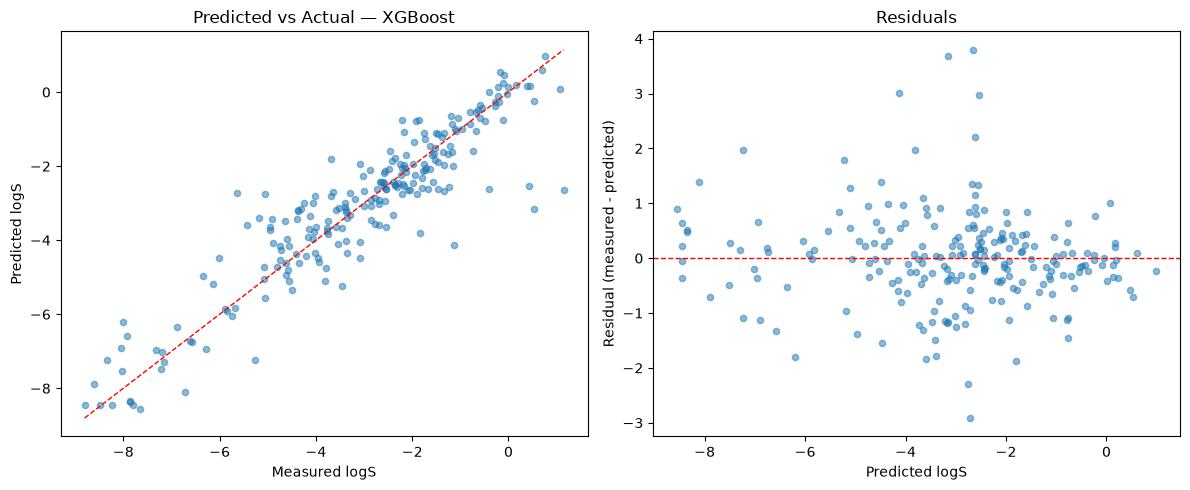

In [12]:
# Pick the best model by test RMSE from what we just computed
model_preds = {
    "Mean baseline":        mean_pred,
    "Delaney's ESOL model": delaney_pred_test,
    "Linear Regression":    lr_pred,
    "Ridge (alpha=1.0)":    ridge_pred,
    "Random Forest":        rf_pred,
    "XGBoost":              xgb_pred,
}
best_name = res_df.index[0]
best_pred = model_preds[best_name]
print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs actual
axes[0].scatter(y_test, best_pred, alpha=0.5, s=20)
lo, hi = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"Predicted vs Actual — {best_name}")

# Residuals
resid = y_test.values - best_pred
axes[1].scatter(best_pred, resid, alpha=0.5, s=20)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (measured - predicted)")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.show()

## 12. Feature importance

For the tree models we can rank features by how much each one contributed
to reducing the loss during training. Reality check: `Minimum Degree` should
come out near zero (it has almost no variance in this dataset).

In [13]:
imp = pd.DataFrame({
    "feature": features,
    "RF importance": rf.feature_importances_,
    "XGB importance": xgb.feature_importances_,
}).sort_values("XGB importance", ascending=False)
imp

,feature,RF importance,XGB importance
3,Number of Rings,0.066258,0.276677
1,Molecular Weight,0.585402,0.190696
2,Number of H-Bond Donors,0.038204,0.159939
5,Polar Surface Area,0.251888,0.152824
4,Number of Rotatable Bonds,0.054228,0.128372
0,Minimum Degree,0.004019,0.091493


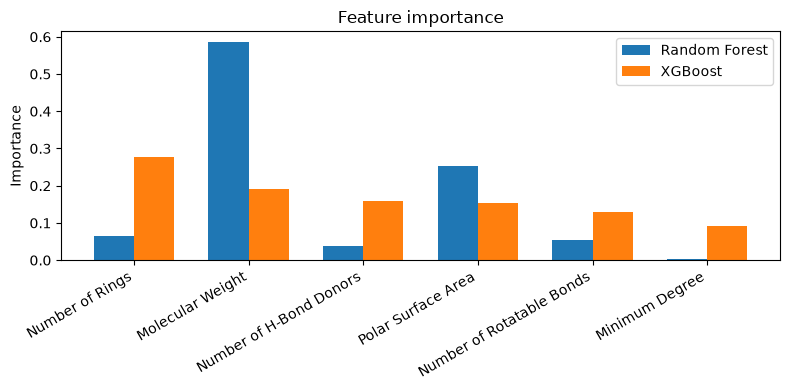

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(features))
width = 0.35
order = imp["feature"].tolist()
rf_vals  = [imp.set_index("feature").loc[f, "RF importance"]  for f in order]
xgb_vals = [imp.set_index("feature").loc[f, "XGB importance"] for f in order]
ax.bar(x - width/2, rf_vals,  width, label="Random Forest")
ax.bar(x + width/2, xgb_vals, width, label="XGBoost")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_ylabel("Importance")
ax.set_title("Feature importance")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
#IMPLEMENT GRID SEARCH CV

kf = KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", Ridge())])

# =========================================================
# DEFINE HYPERPARAMETER GRID FOR RIDGE
# =========================================================


param_grid = {

    "poly__degree": [1, 2, 3, 4, 5],
     "ridge__alpha": [0.001, 0.01, 0.1,1.0,10.0,100.0]
}

#=============================DO GRID_SEARCH_CV================================
# GRID SEARCH CV EXHAUSTIVELY TESTS EVERY COMBINATION OF THE
# SPECIFIED HYPERPARAMETER VALUES USING CROSS-VALIDATION AND
# SELECTS THE COMBINATION THAT GIVES THE BEST VALIDATION SCORE.
# IN OTHER WORDS, IT EXPLORES ALL PERMUTATIONS/COMBINATIONS
# DEFINED BY THE USER'S HYPERPARAMETER GRID.

grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=kf,scoring="neg_root_mean_squared_error",return_train_score=True)

grid.fit(X_train, y_train)      #PERFORM THE SEARCH USING TRAINING DATA

#=====================PRINT THE BEST HYPERPARAMETERS================================
print("\nGrid Search CV completed.")
print("\nBest hyperparameters: ")
print(grid.best_params_)

print("\nBest mean CV RMSE: ")
print(-grid.best_score_)


#===================================FINAL MODEL===============================

final_model = grid.best_estimator_     #FITS THE MODEL WITH THE BEST HYPERPARAMETERS

y_test_pred = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test_pred,y_test)
final_r2 = r2_score(y_test, y_test_pred)

print("\nFINAL TEST RMSE:", final_rmse)
print("\nFINAL TEST R2:", final_r2)


Grid Search CV completed.

Best hyperparameters: 
{'poly__degree': 3, 'ridge__alpha': 1.0}

Best mean CV RMSE: 
0.9614945315750875

FINAL TEST RMSE: 1.056547773010769

FINAL TEST R2: 0.7638376126409812


In [7]:
#GRID CV for RANDOM FOREST ALGORITHM 
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
kf = KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

param_grid = {"n_estimators":[100,200,500],
             "max_depth":[None,5,10,20],
             "min_samples_leaf":[1,2,4],
             "max_features":[1.0,"sqrt"]}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=kf,scoring="neg_root_mean_squared_error",return_train_score=True,
                       n_jobs=2,pre_dispatch=2)

grid_rf.fit(X_train,y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV RMSE:", -grid_rf.best_score_)

rf_best = grid_rf.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("Test RMSE:",root_mean_squared_error(y_test, y_pred_rf))

print("Test R2:",r2_score(y_test, y_pred_rf))


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV RMSE: 0.8527332265210822
Test RMSE: 0.8747565559792112
Test R2: 0.8381149049393255
